# Deliverable 2 — Bayesian Spatial Search

Table of contents

1. Setup
2. Bild the prior
3. Choose mission (Cell A) 
4. Input result (Cell B) - posterior update
5. Save mission in csv

Iterate between 3 and 4 if not found.


## 1. Setup and grid inspection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    NX, NY, X_E, V_PLANE, V_WIND, V_DRIFT, BUDGET_TOTAL,
    load_grid, grid_to_arrays,
    build_prior, detection_probability, calibration_table,
    coverage_mask, mission_cost, posterior_update,
    expected_detection, search_best_mission,
    plot_grid_features, plot_distribution, plot_proposed_mission,
    make_mission_record, save_missions_log,
    simulate_strategy,
)

TEAM_ID = "M4204"

grid_df = load_grid("grid_dataset.csv")
depth_arr, rough_arr, xs, ys = grid_to_arrays(grid_df)
print(f"Loaded {len(grid_df)} cells. Grid: {NX}x{NY}.")

C:\Users\Miki\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Loaded 1750 cells. Grid: 50x35.


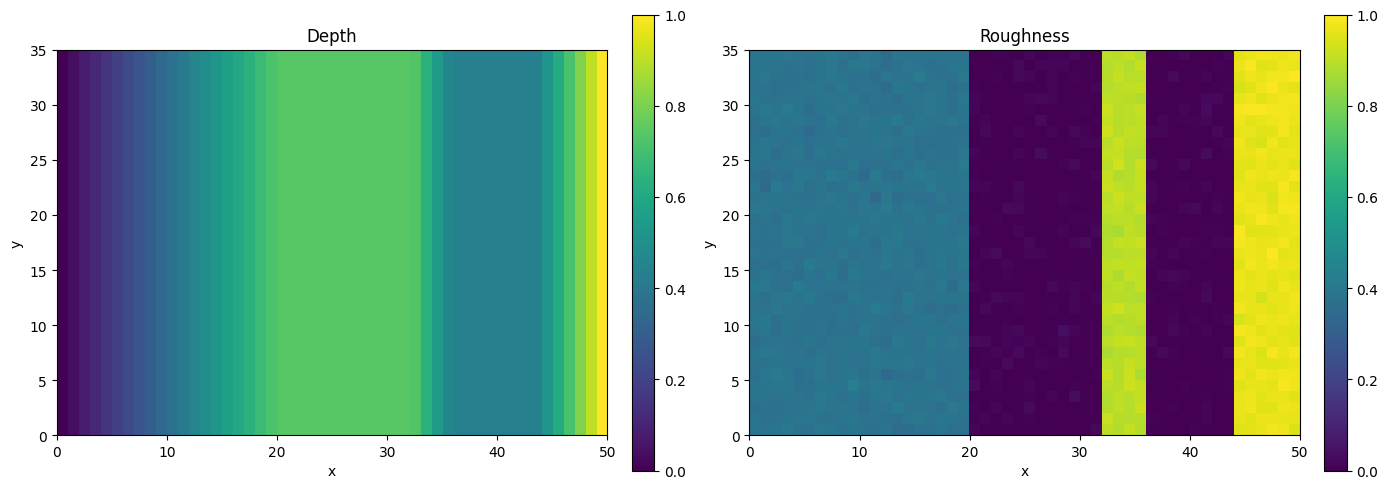

In [2]:
plot_grid_features(grid_df)
plt.show()

## 2. Prior construction

Monte Carlo sampling of
$$
Z = x_E + \alpha\,v_{\text{plane}} + \tau\,(v_{\text{wind}} + v_{\text{drift}}) + 1.5 \epsilon + \eta\,\hat{n}_{\perp}.
$$
with $\alpha \sim \mathcal{N}(1.5, 0.5^2)$ (Witness 2: 'farther along the trajectory'), $\tau \sim \mathcal{N}(1.0, 0.4^2)$ (uncertain drift time), isotropic noise $\mathcal{N}(0, 1.5^2 I)$ for unmodeled effects, and a perpendicular-to-trajectory term $\mathcal{N}(0, 1.0^2)$ encoding Witness 2's 'slightly off to one side'.

Prior peak: cell (15, 12), mass 0.01874
E[Z] = (15.50, 11.75)
Prior mass inside grid: 1.0000


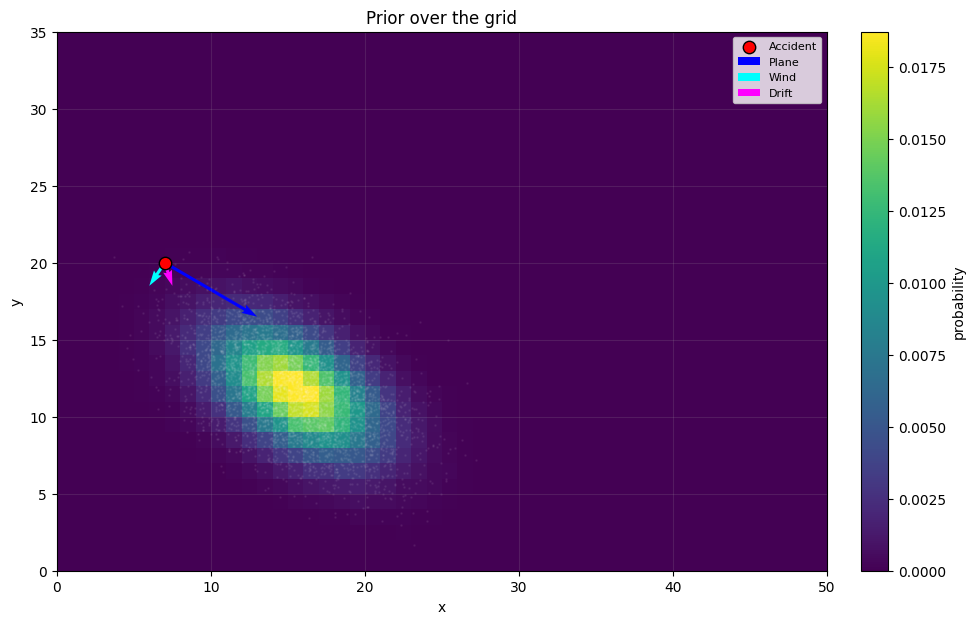

In [3]:
prior, samples = build_prior(
    n_samples=200_000,
    alpha_mean=1.5, alpha_std=0.5,
    tau_mean=1.0,   tau_std=0.4,
    iso_std=1.5,    perp_std=1.0,
    seed=42,
)
iy, ix = np.unravel_index(np.argmax(prior), prior.shape)
ex = float(np.sum(prior * (np.arange(NX) + 0.5)))
ey = float(np.sum(prior * (np.arange(NY) + 0.5)[:, None]))
print(f"Prior peak: cell ({ix}, {iy}), mass {prior.max():.5f}")
print(f"E[Z] = ({ex:.2f}, {ey:.2f})")
print(f"Prior mass inside grid: {prior.sum():.4f}")

plot_distribution(prior, title="Prior over the grid", samples=samples[:5000])
plt.show()

## 3. Detection model

$$
\rho_{tj} = 1 - \exp\!\Big(-e_t \cdot \kappa\,\exp(-\gamma_d\,d_j - \gamma_r\,r_j)\Big)
$$
(EXPLAINED IN THE REPORT) 

In [4]:
KAPPA, GAMMA_D, GAMMA_R = 0.9, 1.8, 1.5 #THIS CHOICE IS JUSTIFIED IN THE REPORT !!
calibration_table(KAPPA, GAMMA_D, GAMMA_R)

Calibration: kappa=0.9, gamma_d=1.8, gamma_r=1.5
------------------------------------------------------------------------------
  Mission 1: moderate depth, smooth, e=1 -> rho=0.219  target=[0.25,0.40]  OFF
  Mission 2: shallow, smooth, e=3        -> rho=0.826  target=[0.85,0.95]  OFF
  Mission 3: deep, rough, e=3            -> rho=0.151  target=[0.20,0.35]  OFF
  Mission 4: moderate, irregular, e=2    -> rho=0.319  target=[0.40,0.55]  OFF


## 4. Initialise mission state

In [5]:
budget_remaining = BUDGET_TOTAL
mission_history = []
log_records = []
posterior = prior.copy()
print(f"Initial budget: {budget_remaining}")

Initial budget: 530


## 5. Mission selection + update loop

**Run cell A** to propose a mission. Submit it. **Edit `s_observed` in cell B** and run it to update.

### Cell A: propose next mission

In [11]:
best, top_df = search_best_mission(
    posterior, depth_arr, rough_arr,
    budget_remaining=budget_remaining,
    efforts=(1, 2, 3),
    min_width=4, max_width=18, min_height=4, max_height=14,
    min_cells=50,        # exploration: force a meaningful sweep
    min_p_detect=0.2,   # exploration: require >=20%% expected detection
    step=1, kappa=KAPPA, gamma_d=GAMMA_D, gamma_r=GAMMA_R,
    verbose=True,
)
print(f"\nProposed mission {len(mission_history) + 1}:")
print(f"  x_min={best['x_min']}, x_max={best['x_max']}, "
      f"y_min={best['y_min']}, y_max={best['y_max']}, e={best['effort']}")
print(f"  cells={best['n_cells']}, cost={best['cost']}, "
      f"budget_after={budget_remaining - best['cost']}")
print(f"  P(detect)={best['p_detect']:.3f}, efficiency={best['efficiency']:.4f}")

plot_proposed_mission(posterior, best, depth_arr, rough_arr,
                      past_missions=mission_history,
                      kappa=KAPPA, gamma_d=GAMMA_D, gamma_r=GAMMA_R)
plt.show()

RuntimeError: No feasible mission within budget=86, min_cells=50, min_p_detect=0.2. Try relaxing one of the constraints.

### Cell B: enter outcome and update



DETECTED on mission 3! Posterior is now localised within the searched rectangle.
Posterior peak: cell (16, 11), mass 0.02989


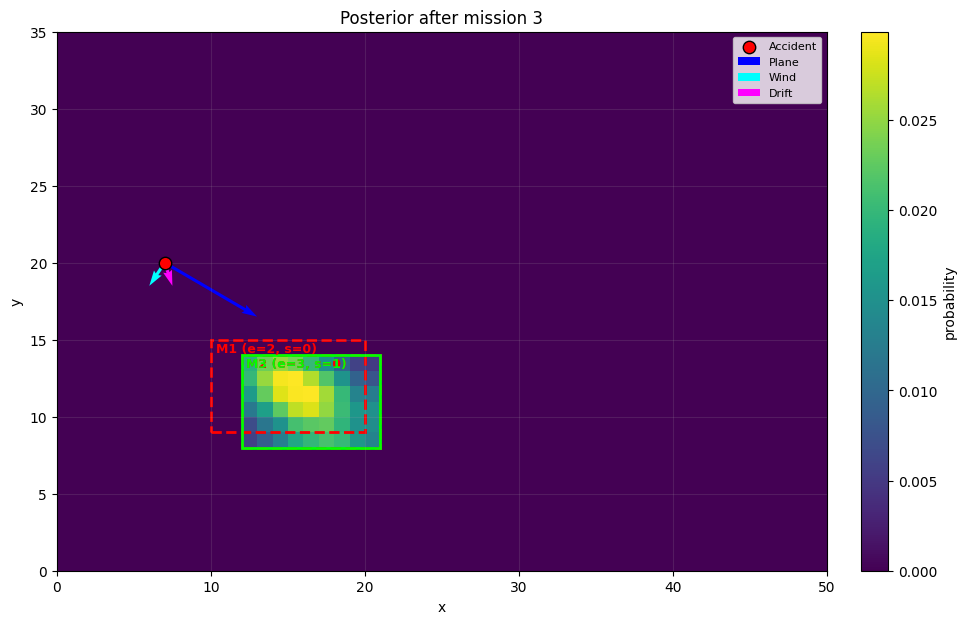

In [10]:
s_observed = 1 # és 0 si no es troba i 1 si es troba 

mission_done = {**best, "s": s_observed}
mission_history.append(mission_done)
budget_remaining -= mission_done["cost"]
log_records.append(make_mission_record(
    TEAM_ID, mission_id=len(mission_history),
    mission=mission_done, budget_remaining=budget_remaining,
))
posterior = posterior_update(posterior, mission_done, depth_arr, rough_arr,
                              KAPPA, GAMMA_D, GAMMA_R)
if s_observed == 1:
    print(f"DETECTED on mission {len(mission_history)}! Posterior is now "
          "localised within the searched rectangle.")
else:
    print(f"Mission {len(mission_history)}: no detection. "
          f"Remaining budget: {budget_remaining}")
iy, ix = np.unravel_index(np.argmax(posterior), posterior.shape)
print(f"Posterior peak: cell ({ix}, {iy}), mass {posterior.max():.5f}")

plot_distribution(posterior,
                  title=f"Posterior after mission {len(mission_history)}",
                  missions=mission_history)
plt.show()

Re-run Cell A and Cell B for each subsequent mission. Budget is enforced automatically.

## 6. Save mission log

In [13]:
save_missions_log(log_records, "missions.csv")
print(f"Saved {len(log_records)} missions.")
pd.DataFrame(log_records)

Saved 2 missions.


,team_id,mission_id,x_min,x_max,y_min,y_max,effort,n_cells,cost,s_t,budget_remaining,timestamp
0,M4204,1,10,20,9,15,2,60,120,0,410,2026-05-23T16:32:33.451826+00:00
1,M4204,2,12,21,8,14,3,54,162,1,248,2026-05-24T11:18:44.553292+00:00
